In [2]:
import pandas as pd
import glob
from obspy.clients.fdsn import Client
import obspy
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import seisbench.models as sbm

import numpy as np

## The goal of this notebook 

- gather daily detections at all the stations
- find the events that were commonly detected at atleast four stations
- plot waveforms and probability curves of such events

In [3]:
# Compute yesterday’s date in the same format as filenames
yesterday = (datetime.utcnow() - timedelta(days=0)).strftime("%Y-%m-%d")

yesterday  = '2025-08-08'

# Glob files from logs folder using that date
event_files = glob.glob(f"logs/*_{yesterday}_events.csv")


# Load each into a DataFrame
dfs = [pd.read_csv(f) for f in event_files]

# Check how many files loaded
print(f"Loaded {len(dfs)} event files")

Loaded 8 event files


In [4]:
dfs[0]

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time
0,RCM,UW,eq,4.453158,0.353026,0.659610,500,512,2025-08-07T22:19:31.730682Z,2025-08-07T22:21:31.730682Z
1,RCM,UW,eq,3.685087,0.426663,0.705793,567,575,2025-08-07T22:30:41.730682Z,2025-08-07T22:32:01.730682Z
2,RCM,UW,eq,3.640498,0.379791,0.626749,1515,1524,2025-08-08T01:08:41.730682Z,2025-08-08T01:10:11.730682Z
3,RCM,UW,eq,3.376107,0.391072,0.645376,2878,2886,2025-08-08T04:55:51.730682Z,2025-08-08T04:57:11.730682Z
4,RCM,UW,eq,4.249304,0.443009,0.727967,2926,2935,2025-08-08T05:03:51.730682Z,2025-08-08T05:05:21.730682Z
...,...,...,...,...,...,...,...,...,...,...
228,RCM,UW,su,24.884794,0.397491,0.785864,8085,8147,2025-08-08T19:23:41.730682Z,2025-08-08T19:34:01.730682Z
229,RCM,UW,su,69.390834,0.448556,0.849877,8149,8303,2025-08-08T19:34:21.730682Z,2025-08-08T20:00:01.730682Z
230,RCM,UW,su,10.232447,0.495866,0.858190,8304,8324,2025-08-08T20:00:11.730682Z,2025-08-08T20:03:31.730682Z
231,RCM,UW,su,31.535612,0.401092,0.742324,8325,8403,2025-08-08T20:03:41.730682Z,2025-08-08T20:16:41.730682Z


In [275]:
# Combine all station events into one DataFrame
df_all = pd.concat(dfs, ignore_index=True)

df_all

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start,num_stations,stations,most_common_class,mean_auc,mean_max
0,RCM,UW,eq,4.146778,0.267673,0.511471,93.0,108.0,2025-08-26T17:36:19.126863Z,2025-08-26T17:38:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1,RCM,UW,eq,4.214696,0.435244,0.820838,117.0,126.0,2025-08-26T17:40:19.126863Z,2025-08-26T17:41:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
2,RCM,UW,eq,2.891248,0.340238,0.548002,133.0,141.0,2025-08-26T17:42:59.126863Z,2025-08-26T17:44:19.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
3,RCM,UW,eq,6.713982,0.312559,0.532496,154.0,175.0,2025-08-26T17:46:29.126863Z,2025-08-26T17:49:59.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
4,RCM,UW,eq,3.831518,0.444477,0.747202,241.0,249.0,2025-08-26T18:00:59.126863Z,2025-08-26T18:02:19.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,MILD,CC,su,12.316324,0.520143,0.872057,8337.0,8360.0,2025-08-27T16:30:19.126863Z,2025-08-27T16:34:09.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1339,MILD,CC,su,7.400092,0.359173,0.566848,8392.0,8412.0,2025-08-27T16:39:29.126863Z,2025-08-27T16:42:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1340,MILD,CC,su,2.494530,0.393236,0.566685,8416.0,8422.0,2025-08-27T16:43:29.126863Z,2025-08-27T16:44:29.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1341,NaN,NaN,NaN,NaN,0.396025,NaN,NaN,NaN,NaN,NaN,2025-08-26 17:20:50+00:00,4.0,"['STAR', 'STAR', 'STAR', 'OBSR', 'PANH', 'MILD']",eq,4.236582,0.677841


In [276]:
# Convert start_time to datetime if it's not already
df_all["start_time"] = pd.to_datetime(df_all["start_time"])

In [277]:
df_all

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start,num_stations,stations,most_common_class,mean_auc,mean_max
0,RCM,UW,eq,4.146778,0.267673,0.511471,93.0,108.0,2025-08-26 17:36:19.126863+00:00,2025-08-26T17:38:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1,RCM,UW,eq,4.214696,0.435244,0.820838,117.0,126.0,2025-08-26 17:40:19.126863+00:00,2025-08-26T17:41:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
2,RCM,UW,eq,2.891248,0.340238,0.548002,133.0,141.0,2025-08-26 17:42:59.126863+00:00,2025-08-26T17:44:19.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
3,RCM,UW,eq,6.713982,0.312559,0.532496,154.0,175.0,2025-08-26 17:46:29.126863+00:00,2025-08-26T17:49:59.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
4,RCM,UW,eq,3.831518,0.444477,0.747202,241.0,249.0,2025-08-26 18:00:59.126863+00:00,2025-08-26T18:02:19.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,MILD,CC,su,12.316324,0.520143,0.872057,8337.0,8360.0,2025-08-27 16:30:19.126863+00:00,2025-08-27T16:34:09.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1339,MILD,CC,su,7.400092,0.359173,0.566848,8392.0,8412.0,2025-08-27 16:39:29.126863+00:00,2025-08-27T16:42:49.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1340,MILD,CC,su,2.494530,0.393236,0.566685,8416.0,8422.0,2025-08-27 16:43:29.126863+00:00,2025-08-27T16:44:29.126863Z,NaN,NaN,NaN,NaN,NaN,NaN
1341,NaN,NaN,NaN,NaN,0.396025,NaN,NaN,NaN,NaT,NaN,2025-08-26 17:20:50+00:00,4.0,"['STAR', 'STAR', 'STAR', 'OBSR', 'PANH', 'MILD']",eq,4.236582,0.677841


In [278]:
# Round to nearest 10s window (you can try 5s or 15s too)
df_all["rounded_start"] = df_all["start_time"].dt.round("10s")

In [279]:
df_all

,station,network,class,auc,mean_prob,max_prob,start_index,end_index,start_time,end_time,rounded_start,num_stations,stations,most_common_class,mean_auc,mean_max
0,RCM,UW,eq,4.146778,0.267673,0.511471,93.0,108.0,2025-08-26 17:36:19.126863+00:00,2025-08-26T17:38:49.126863Z,2025-08-26 17:36:20+00:00,NaN,NaN,NaN,NaN,NaN
1,RCM,UW,eq,4.214696,0.435244,0.820838,117.0,126.0,2025-08-26 17:40:19.126863+00:00,2025-08-26T17:41:49.126863Z,2025-08-26 17:40:20+00:00,NaN,NaN,NaN,NaN,NaN
2,RCM,UW,eq,2.891248,0.340238,0.548002,133.0,141.0,2025-08-26 17:42:59.126863+00:00,2025-08-26T17:44:19.126863Z,2025-08-26 17:43:00+00:00,NaN,NaN,NaN,NaN,NaN
3,RCM,UW,eq,6.713982,0.312559,0.532496,154.0,175.0,2025-08-26 17:46:29.126863+00:00,2025-08-26T17:49:59.126863Z,2025-08-26 17:46:30+00:00,NaN,NaN,NaN,NaN,NaN
4,RCM,UW,eq,3.831518,0.444477,0.747202,241.0,249.0,2025-08-26 18:00:59.126863+00:00,2025-08-26T18:02:19.126863Z,2025-08-26 18:01:00+00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338,MILD,CC,su,12.316324,0.520143,0.872057,8337.0,8360.0,2025-08-27 16:30:19.126863+00:00,2025-08-27T16:34:09.126863Z,2025-08-27 16:30:20+00:00,NaN,NaN,NaN,NaN,NaN
1339,MILD,CC,su,7.400092,0.359173,0.566848,8392.0,8412.0,2025-08-27 16:39:29.126863+00:00,2025-08-27T16:42:49.126863Z,2025-08-27 16:39:30+00:00,NaN,NaN,NaN,NaN,NaN
1340,MILD,CC,su,2.494530,0.393236,0.566685,8416.0,8422.0,2025-08-27 16:43:29.126863+00:00,2025-08-27T16:44:29.126863Z,2025-08-27 16:43:30+00:00,NaN,NaN,NaN,NaN,NaN
1341,NaN,NaN,NaN,NaN,0.396025,NaN,NaN,NaN,NaT,NaN,NaT,4.0,"['STAR', 'STAR', 'STAR', 'OBSR', 'PANH', 'MILD']",eq,4.236582,0.677841


## Ok so we needed to round off to nearest 10 because of the minor variations in the station detection timing, later all the events that lie within 10s would be merged and counted as one. 

In [280]:
# Group by the rounded start time
grouped = df_all.groupby("rounded_start").agg(
    num_stations=("station", "nunique"),
    stations=("station", lambda x: list(x)),
    most_common_class=("class", lambda x: x.mode()[0] if not x.mode().empty else "unknown"),
    mean_auc=("auc", "mean"),
    mean_max=("max_prob", "mean"),
    mean_prob=("mean_prob", "mean")
).reset_index()

# Show results
print(grouped.head())


              rounded_start  num_stations  \
0 2025-08-26 17:20:50+00:00             4   
1 2025-08-26 17:21:00+00:00             1   
2 2025-08-26 17:22:00+00:00             1   
3 2025-08-26 17:22:10+00:00             1   
4 2025-08-26 17:22:20+00:00             1   

                               stations most_common_class   mean_auc  \
0  [STAR, STAR, STAR, OBSR, PANH, MILD]                eq   4.236582   
1                                [STAR]                eq   2.908286   
2                                [STAR]                eq  15.235210   
3                                [STAR]                eq  10.488824   
4                                [STAR]                su   9.112819   

   mean_max  mean_prob  
0  0.677841   0.396025  
1  0.585453   0.380750  
2  0.937999   0.513747  
3  0.914178   0.508663  
4  0.945347   0.463678  


In [281]:
grouped

,rounded_start,num_stations,stations,most_common_class,mean_auc,mean_max,mean_prob
0,2025-08-26 17:20:50+00:00,4,"[STAR, STAR, STAR, OBSR, PANH, MILD]",eq,4.236582,0.677841,0.396025
1,2025-08-26 17:21:00+00:00,1,[STAR],eq,2.908286,0.585453,0.380750
2,2025-08-26 17:22:00+00:00,1,[STAR],eq,15.235210,0.937999,0.513747
3,2025-08-26 17:22:10+00:00,1,[STAR],eq,10.488824,0.914178,0.508663
4,2025-08-26 17:22:20+00:00,1,[STAR],su,9.112819,0.945347,0.463678
...,...,...,...,...,...,...,...
1172,2025-08-27 17:10:40+00:00,1,[RCM],px,3.927280,0.776683,0.456366
1173,2025-08-27 17:13:10+00:00,1,[RCM],px,4.563829,0.635523,0.336483
1174,2025-08-27 17:14:00+00:00,1,[RCM],su,13.531041,0.764936,0.442507
1175,2025-08-27 17:17:40+00:00,1,[RER],su,3.218385,0.550303,0.332241


## Finding events that were commonly detected at four or more stations. 

In [282]:
# Set threshold
N = 4

# Filter the grouped DataFrame
common_events = grouped[grouped["num_stations"] >= N].copy()

# View or save
print(common_events)

                rounded_start  num_stations  \
0   2025-08-26 17:20:50+00:00             4   
228 2025-08-26 19:06:00+00:00             4   

                                 stations most_common_class  mean_auc  \
0    [STAR, STAR, STAR, OBSR, PANH, MILD]                eq  4.236582   
228               [RCM, OBSR, PANH, PARA]                px  5.784911   

     mean_max  mean_prob  
0    0.677841   0.396025  
228  0.645104   0.374820  


In [283]:
common_events

,rounded_start,num_stations,stations,most_common_class,mean_auc,mean_max,mean_prob
0,2025-08-26 17:20:50+00:00,4,"[STAR, STAR, STAR, OBSR, PANH, MILD]",eq,4.236582,0.677841,0.396025
228,2025-08-26 19:06:00+00:00,4,"[RCM, OBSR, PANH, PARA]",px,5.784911,0.645104,0.374820


## We want to plot these events, their waveforms and probability curves

In [284]:
# Load model
model = sbm.QuakeXNet.from_pretrained("base", version_str = '3')



In [285]:

def plot_event_waveforms(event_row, duration=300, peak_thresh=0.50):
    client      = Client("IRIS")
    event_time  = UTCDateTime(event_row["rounded_start"])
    stations    = event_row["stations"]
    target_cls  = event_row["most_common_class"]

    fig, ax = plt.subplots(figsize=(10, 2 * len(stations)))

    y_offsets = []
    for i, sta in enumerate(stations):
        try:
            st = client.get_waveforms("*", sta, "*", "*HZ",
                                      starttime=event_time +80,
                                      endtime=event_time + duration)
            st.resample(50)

            # ── inference ───────────────────────────────────────────────
            probs_st = model.annotate(st, stride=500)
            probs_tr = probs_st.select(channel=f"QuakeXNet_{target_cls}")[0]
            t_probs  = probs_tr.times() + 50
            d_probs  = probs_tr.data

            # ── waveform prep ───────────────────────────────────────────
            st.detrend("linear"); st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)
            tr       = st[0]
            t_wave   = tr.times("relative")
            y_wave   = tr.data / np.abs(tr.data).max()

            # ── plot ────────────────────────────────────────────────────
            offset = 2 * i
            y_offsets.append(offset)
            ax.plot(t_wave,  y_wave + offset,  lw=0.6, color="black")
            ax.plot(t_probs, d_probs + offset, lw=1.2)

            # annotate peaks above threshold
            peaks = np.where((d_probs[1:-1] > d_probs[:-2]) &
                             (d_probs[1:-1] > d_probs[2:]) &
                             (d_probs[1:-1] >= peak_thresh))[0] + 1
            for p in peaks:
                ax.text(t_probs[p], d_probs[p] + offset + 0.05,
                        f"{d_probs[p]:.2f}", ha="center", va="bottom",
                        fontsize=7, color="darkblue")
        except Exception as e:
            print(f"❌ {sta}: {e}")

    # ── styling ────────────────────────────────────────────────────────
    ax.axvline(0, color="red", ls="--")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}")

    # put station names on y-axis at the row centers
    ax.set_yticks(y_offsets)
    ax.set_yticklabels(stations)
    ax.set_ylabel("Station")

    ax.set_xlim(0, 60)
    ax.set_ylim(-1, 2 * len(stations))
    plt.tight_layout()
    plt.show()


In [286]:
eqt_preds = eqt_model.annotate(st)

/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)


In [287]:
eqt_preds[0].times()

array([0.0000e+00, 1.0000e-02, 2.0000e-02, ..., 2.1999e+02, 2.2000e+02,
       2.2001e+02])

In [288]:
def plot_event_waveforms(event_row, duration=300, peak_thresh=0.50):
    client      = Client("IRIS")
    event_time  = UTCDateTime(event_row["rounded_start"])
    stations    = event_row["stations"]
    target_cls  = event_row["most_common_class"]

    fig, ax = plt.subplots(figsize=(10, 2 * len(stations)))

    y_offsets = []
    for i, sta in enumerate(stations):
        try:
            st = client.get_waveforms("*", sta, "*", "*HZ",
                                      starttime=event_time,
                                      endtime=event_time + duration)
            st.resample(50)
            

            # ── inference ───────────────────────────────────────────────
            probs_st = eqt_model.annotate(st)
            

        
            probs_tr_0 = probs_st[0]
            probs_tr_1 = probs_st[1]
            probs_tr_2 = probs_st[2]
            
            t_probs  = probs_tr_0.times() 
            
            
            d_probs_0  = probs_tr_0.data*2
            d_probs_1 = probs_tr_1.data*2
            d_probs_2 = probs_tr_2.data*2

            # ── waveform prep ───────────────────────────────────────────
            st.detrend("linear"); st.taper(0.01)
            st.filter("bandpass", freqmin=1, freqmax=20)
            tr       = st[0]
            t_wave   = tr.times("relative")
            y_wave   = tr.data / np.abs(tr.data).max()

            # ── plot ────────────────────────────────────────────────────
            offset = 2 * i
            y_offsets.append(offset)
            ax.plot(t_wave,  y_wave + offset,  lw=0.6, color="black")
            
            
            t_max = t_wave[np.argmax(y_wave+offset)]
         
            ax.plot(t_probs, d_probs_0 + offset, lw=1.2, color = 'orange')
            ax.plot(t_probs, d_probs_1 + offset, lw=1.2, color = 'blue')
            ax.plot(t_probs, d_probs_2 + offset, lw=1.2, color = 'green')

            # annotate peaks above threshold
            """
            peaks = np.where((d_probs[1:-1] > d_probs[:-2]) &
                             (d_probs[1:-1] > d_probs[2:]) &
                             (d_probs[1:-1] >= peak_thresh))[0] + 1
            for p in peaks:
                ax.text(t_probs[p], d_probs[p] + offset + 0.05,
                        f"{d_probs[p]:.2f}", ha="center", va="bottom",
                        fontsize=7, color="darkblue")
            """
        except Exception as e:
            print(f"❌ {sta}: {e}")

    # ── styling ────────────────────────────────────────────────────────
    ax.axvline(0, color="red", ls="--")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Event @ {event_time.isoformat()} — cls = {target_cls.upper()}")

    # put station names on y-axis at the row centers
    ax.set_yticks(y_offsets)
    ax.set_yticklabels(stations)
    ax.set_ylabel("Station")

    ax.set_xlim( t_max - 50, t_max + 50)
    ax.set_ylim(-1, 2 * len(stations))
    plt.tight_layout()
    plt.show()


/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/

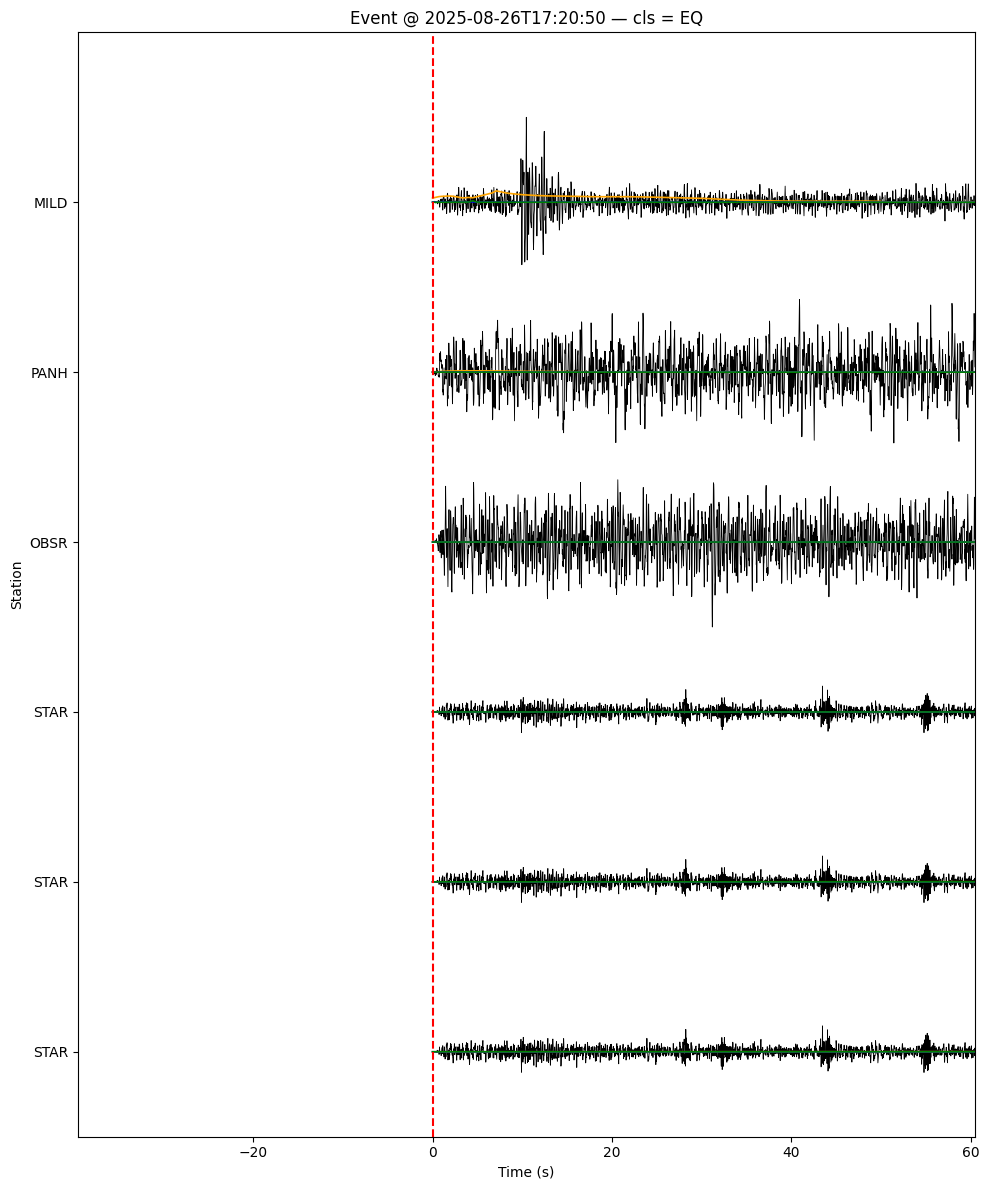

/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)


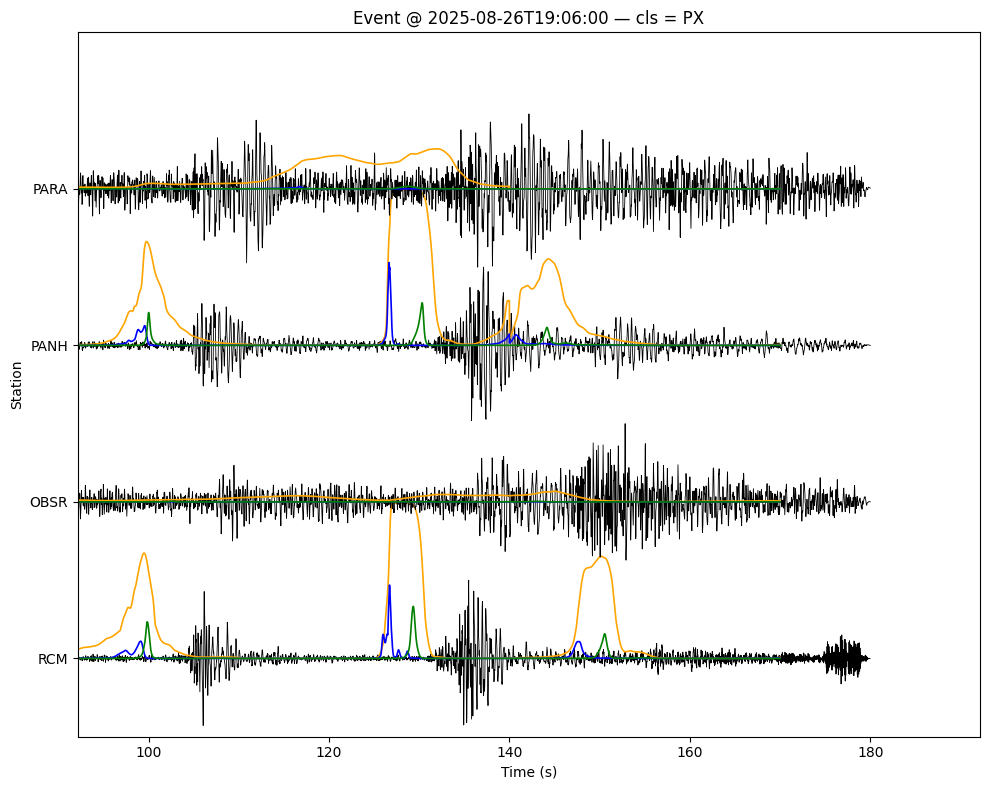

In [289]:
for i in range(len(common_events)):
    plot_event_waveforms(common_events.iloc[i], duration= 180)


## Loading various pretrained picking models

In [290]:
# Various pre-trained weights for PhaseNet
# pn_model = sbm.PhaseNet.from_pretrained("ethz")
# pn_model = sbm.PhaseNet.from_pretrained("instance")
# pn_model = sbm.PhaseNet.from_pretrained("scedc")
pn_model = sbm.PhaseNet.from_pretrained("stead")
# pn_model = sbm.PhaseNet.from_pretrained("geofon")
# pn_model = sbm.PhaseNet.from_pretrained("neic")

# Various pre-trained weights for EQT
eqt_model = sbm.EQTransformer.from_pretrained("original")
#eqt_model = sbm.EQTransformer.from_pretrained("ethz")
# eqt_model = sbm.EQTransformer.from_pretrained("instance")
#eqt_model = sbm.EQTransformer.from_pretrained("scedc")
# eqt_model = sbm.EQTransformer.from_pretrained("stead")
# eqt_model = sbm.EQTransformer.from_pretrained("geofon")

# Various pre-trained weights for GPD
# gpd_model = sbm.GPD.from_pretrained("original")
# gpd_model = sbm.GPD.from_pretrained("ethz")
# gpd_model = sbm.GPD.from_pretrained("scedc")
gpd_model = sbm.GPD.from_pretrained("stead")
# gpd_model = sbm.GPD.from_pretrained("geofon")
# gpd_model = sbm.GPD.from_pretrained("neic")

In [213]:
pn_model.cuda();
eqt_model.cuda();
gpd_model.cuda();

In [ ]:


client = Client("IRIS")
event_time  = UTCDateTime(event_row["rounded_start"])
stream = client.get_waveforms(network="CC", station="PANH", location="*", channel="*H?", 
                              starttime= event_time, 
                              endtime=t+300)


fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(111)
for i in range(3):
    ax.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
ax.legend();